In [167]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

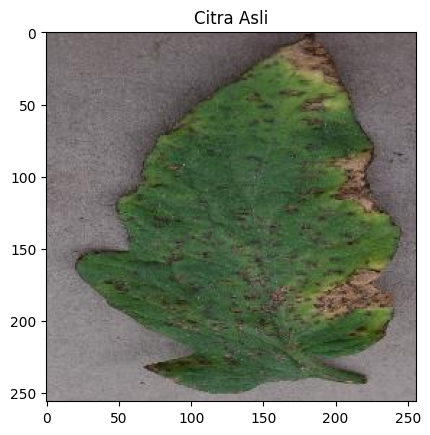

In [168]:
img = cv2.imread('archive/tomato/pilihan.JPG')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.title('Citra Asli')
plt.show()

In [169]:
def ekualisasi_histogram(citra):
    tinggi, lebar = citra.shape
    histogram = np.zeros(256, dtype=int)
    for baris in range(tinggi):
        for kolom in range(lebar):
            pixel = int(citra[baris, kolom])
            histogram[pixel] += 1
    cdf = np.zeros(256, dtype=int)
    total = 0
    for indeks in range(256):
        total += histogram[indeks]
        cdf[indeks] = total
    nilai_min = 0
    for i in range(256):
        if cdf[i] > 0:
            nilai_min = cdf[i]
            break
    total_pixel = tinggi * lebar
    hasil = np.zeros_like(citra, dtype=np.uint8)
    for baris in range(tinggi):
        for kolom in range(lebar):
            pixel = int(citra[baris, kolom])
            hasil[baris, kolom] = round((cdf[pixel] - nilai_min) / (total_pixel - nilai_min) * 255)
    return hasil

def filtering(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=int)
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total = 0
                    for val in region.ravel():
                        total += int(val)
                    canvas[i, j] = total // area
        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size].ravel()
                    sorted_region = sorted(region)
                    canvas[i, j] = sorted_region[len(sorted_region) // 2]
    return canvas.astype(np.uint8)

def resize(image, new_width, new_height):
    old_height, old_width = image.shape[:2]
    resized_image = np.zeros((new_height, new_width), dtype=np.uint8)
    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)
            resized_image[i, j] = image[y, x]
    return resized_image

def threshold(img, batas):
    baris, kolom = img.shape
    canvas = np.zeros_like(img, dtype=np.uint8)
    for i in range(baris):
        for j in range(kolom):
            if img[i, j] > batas:
                canvas[i, j] = 255
            else:
                canvas[i, j] = 0
    return canvas

def dilasi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))
    for i in range(center, height - center):
        for j in range(center, width - center):
            if image[i, j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k, l] == 1:
                            hasil[i+k-center, j+l-center] = 255
    return hasil

def erosi(citra, mask):
    pad_t, pad_l = mask.shape[0] // 2, mask.shape[1] // 2
    citra_pad = np.pad(citra, ((pad_t, pad_t), (pad_l, pad_l)), mode='constant', constant_values=255)
    hasil = np.zeros_like(citra, dtype=np.uint8)
    for r in range(pad_t, citra_pad.shape[0] - pad_t):
        for c in range(pad_l, citra_pad.shape[1] - pad_l):
            blok = citra_pad[r-pad_t:r+pad_t+1, c-pad_l:c+pad_l+1]
            if np.all(blok[mask == 1] == 255):
                hasil[r-pad_t, c-pad_l] = 255
    return hasil

def opening(img, kernel):
    return dilasi(erosi(img, kernel), kernel)

def closing(img, kernel):
    return erosi(dilasi(img, kernel), kernel)

kernel = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype=np.uint8)

## PERCOBAAN 1

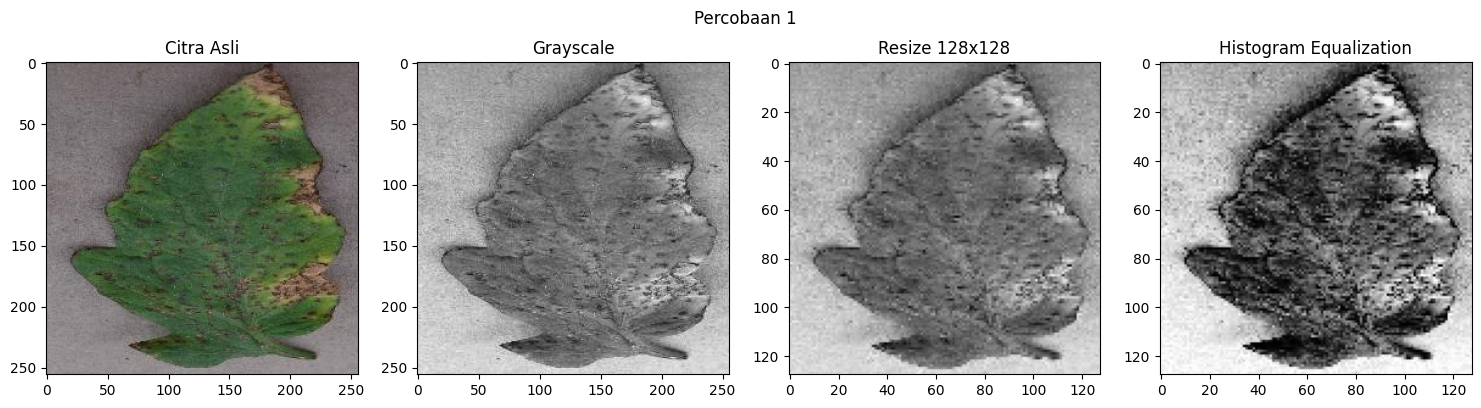

In [170]:
p1_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
p1_resize = resize(p1_gray, 128, 128)
p1_he = ekualisasi_histogram(p1_resize)

plt.figure(figsize=(15, 4))

plt.subplot(1, 4, 1)
plt.imshow(img)
plt.title('Citra Asli')
plt.axis('on')

plt.subplot(1, 4, 2)
plt.imshow(p1_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('on')

plt.subplot(1, 4, 3)
plt.imshow(p1_resize, cmap='gray')
plt.title('Resize 128x128')
plt.axis('on')

plt.subplot(1, 4, 4)
plt.imshow(p1_he, cmap='gray')
plt.title('Histogram Equalization')
plt.axis('on')

plt.suptitle('Percobaan 1')
plt.tight_layout()
plt.show()

## PERCOBAAN 2

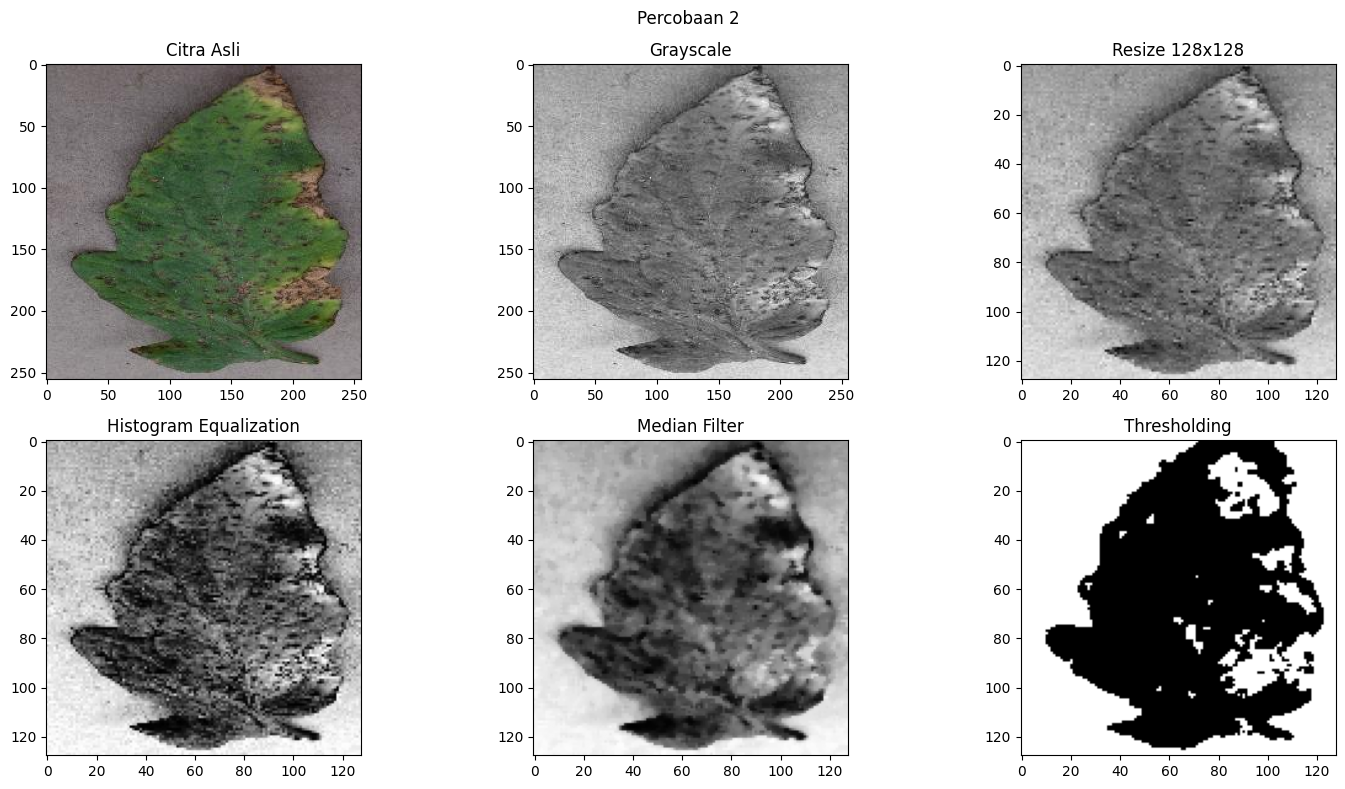

In [171]:
p2_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
p2_resize = resize(p2_gray, 128, 128)
p2_he = ekualisasi_histogram(p2_resize)
p2_median = filtering(p2_he, 3, 'median')
p2_thresh = threshold(p2_median, 127)

plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(img)
plt.title('Citra Asli')
plt.axis('on')

plt.subplot(2, 3, 2)
plt.imshow(p2_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('on')

plt.subplot(2, 3, 3)
plt.imshow(p2_resize, cmap='gray')
plt.title('Resize 128x128')
plt.axis('on')

plt.subplot(2, 3, 4)
plt.imshow(p2_he, cmap='gray')
plt.title('Histogram Equalization')
plt.axis('on')

plt.subplot(2, 3, 5)
plt.imshow(p2_median, cmap='gray')
plt.title('Median Filter')
plt.axis('on')

plt.subplot(2, 3, 6)
plt.imshow(p2_thresh, cmap='gray')
plt.title('Thresholding')
plt.axis('on')

plt.suptitle('Percobaan 2')
plt.tight_layout()
plt.show()


## PERCOBAAN 3

In [172]:
def konvolusiTepi(imageCitra, kernel):
    citra_height, citra_width = imageCitra.shape
    kernel_size = kernel.shape[0]
    pad = kernel_size // 2
    
    padded_image =  np.pad(imageCitra, pad_width=pad,  mode='constant', constant_values=0)
        
    result = np.zeros([citra_height, citra_width])

    for i in range(citra_height):
        for j in range(citra_width):
            region = padded_image[i:i+kernel_size, j:j+kernel_size]
            result[i, j] = np.sum(region * kernel)
            
    return result

In [173]:
def deteksiTepi(imageCitra, kernel_x, kernel_y):
    gradien_x = konvolusiTepi(imageCitra, kernel_x)
    gradien_y = konvolusiTepi(imageCitra, kernel_y)

    result = np.sqrt((gradien_x * gradien_x) + (gradien_y * gradien_y))
    return result

In [174]:
Sx = np.array([[-1,0,1],
               [-2,0,2],
               [-1,0,1]])

Sy = np.array([[1,2,1],
               [0,0,0],
               [-1,-2,-1]])

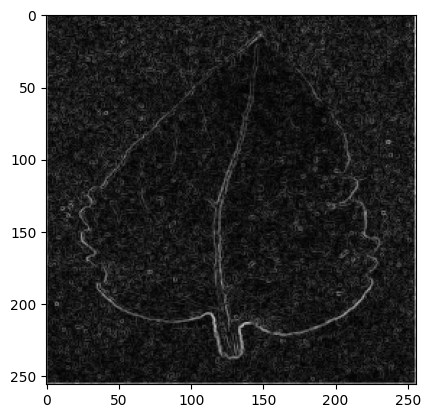

In [175]:
imageTepi = deteksiTepi(p3_gray, Sx, Sy)

plt.imshow(imageTepi, cmap='gray')

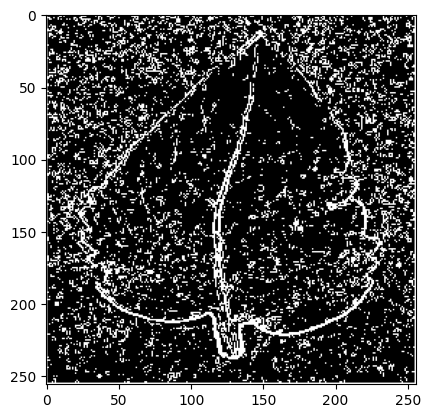

In [176]:
thresholdTangan = threshold(imageTepi, 100)

plt.imshow(thresholdTangan, cmap='gray')

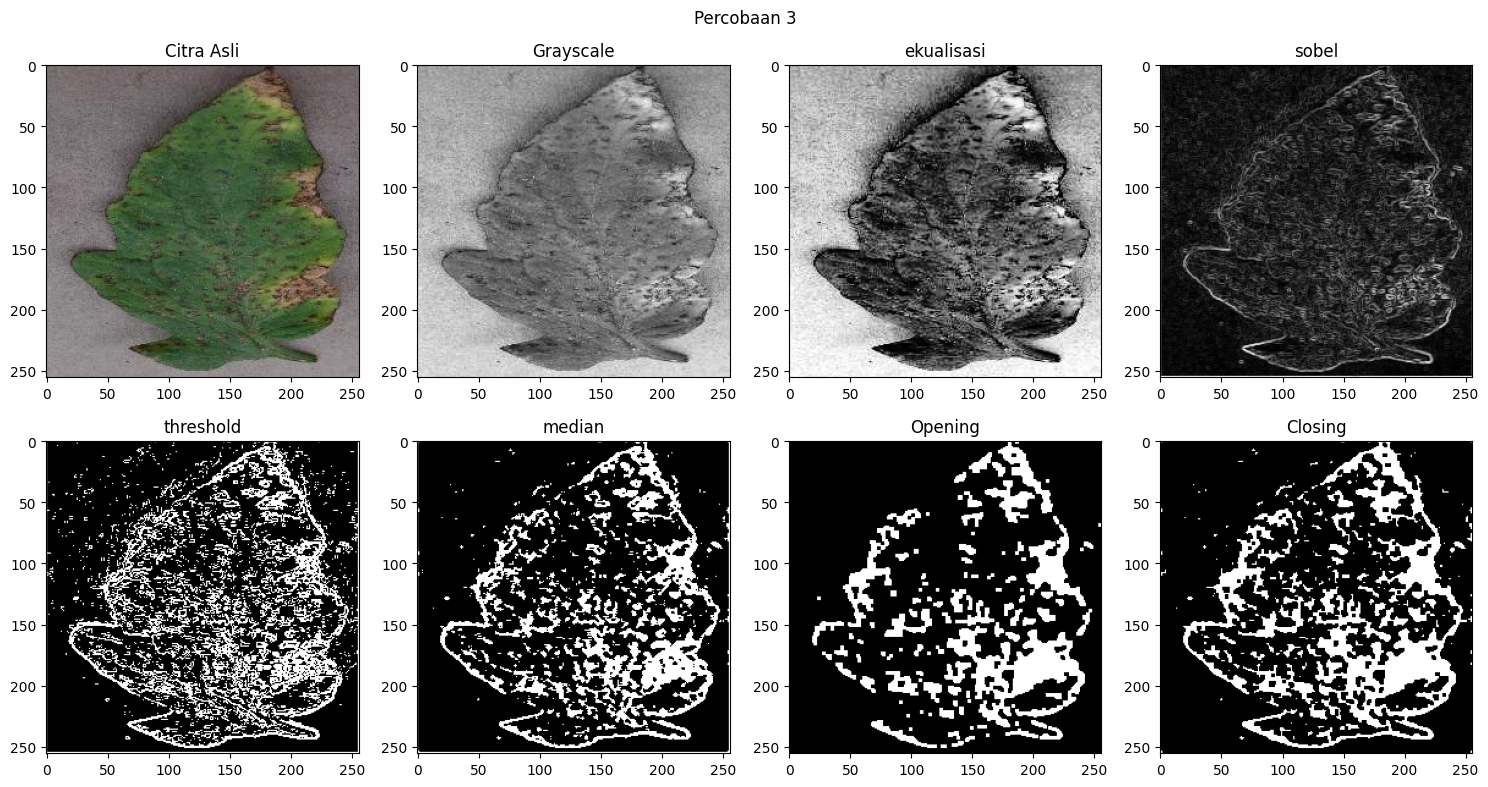

In [177]:
p3_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
p3_he = ekualisasi_histogram(p3_gray)
p3_Tepi = deteksiTepi(p3_he, Sx, Sy)
p3_thresh = threshold(p3_Tepi, 200)
p3_median = filtering(p3_thresh, 3, 'median')

p3_closing = closing(p3_median, kernel)
p3_opening = opening(p3_closing, kernel)

plt.figure(figsize=(15, 8))

plt.subplot(2, 4, 1)
plt.imshow(img)
plt.title('Citra Asli')
plt.axis('on')

plt.subplot(2, 4, 2)
plt.imshow(p3_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('on')

plt.subplot(2, 4, 3)
plt.imshow(p3_he, cmap='gray')
plt.title('ekualisasi')
plt.axis('on')

plt.subplot(2, 4, 4)
plt.imshow(p3_Tepi, cmap='gray')
plt.title('sobel')
plt.axis('on')

plt.subplot(2, 4, 5)
plt.imshow(p3_thresh, cmap='gray')
plt.title('threshold')
plt.axis('on')

plt.subplot(2, 4, 6)
plt.imshow(p3_median, cmap='gray')
plt.title('median')
plt.axis('on')

plt.subplot(2, 4, 7)
plt.imshow(p3_opening, cmap='gray')
plt.title('Opening')
plt.axis('on')

plt.subplot(2, 4, 8)
plt.imshow(p3_closing, cmap='gray')
plt.title('Closing')
plt.axis('on')

plt.suptitle('Percobaan 3')
plt.tight_layout()
plt.show()

In [178]:
img2 = cv2.imread('archive/tomato/septoria.JPG')
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

img3 = cv2.imread('archive/tomato/early.JPG')
img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)

img4 = cv2.imread('archive/tomato/healty.JPG')
img4 = cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)

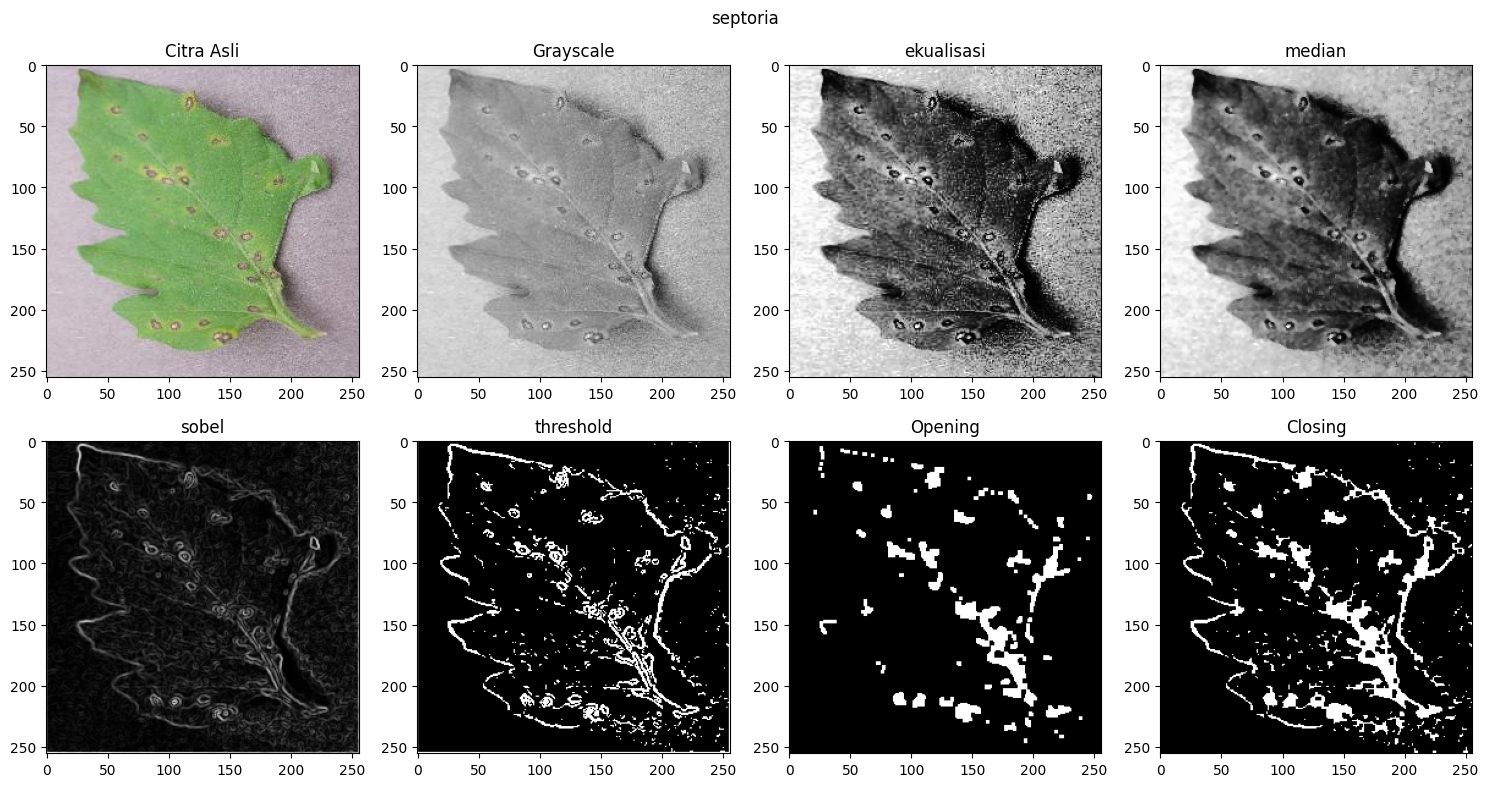

In [186]:
p3_gray = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)
p3_he = ekualisasi_histogram(p3_gray)
p3_median = filtering(p3_he, 3, 'median')
p3_Tepi = deteksiTepi(p3_median, Sx, Sy)
p3_thresh = threshold(p3_Tepi, 200)


p3_closing = closing(p3_thresh, kernel)
p3_opening = opening(p3_closing, kernel)

plt.figure(figsize=(15, 8))

plt.subplot(2, 4, 1)
plt.imshow(img2)
plt.title('Citra Asli')
plt.axis('on')

plt.subplot(2, 4, 2)
plt.imshow(p3_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('on')

plt.subplot(2, 4, 3)
plt.imshow(p3_he, cmap='gray')
plt.title('ekualisasi')
plt.axis('on')

plt.subplot(2, 4, 4)
plt.imshow(p3_median, cmap='gray')
plt.title('median')
plt.axis('on')

plt.subplot(2, 4, 5)
plt.imshow(p3_Tepi, cmap='gray')
plt.title('sobel')
plt.axis('on')

plt.subplot(2, 4, 6)
plt.imshow(p3_thresh, cmap='gray')
plt.title('threshold')
plt.axis('on')

plt.subplot(2, 4, 7)
plt.imshow(p3_opening, cmap='gray')
plt.title('Opening')
plt.axis('on')

plt.subplot(2, 4, 8)
plt.imshow(p3_closing, cmap='gray')
plt.title('Closing')
plt.axis('on')

plt.suptitle('septoria')
plt.tight_layout()
plt.show()

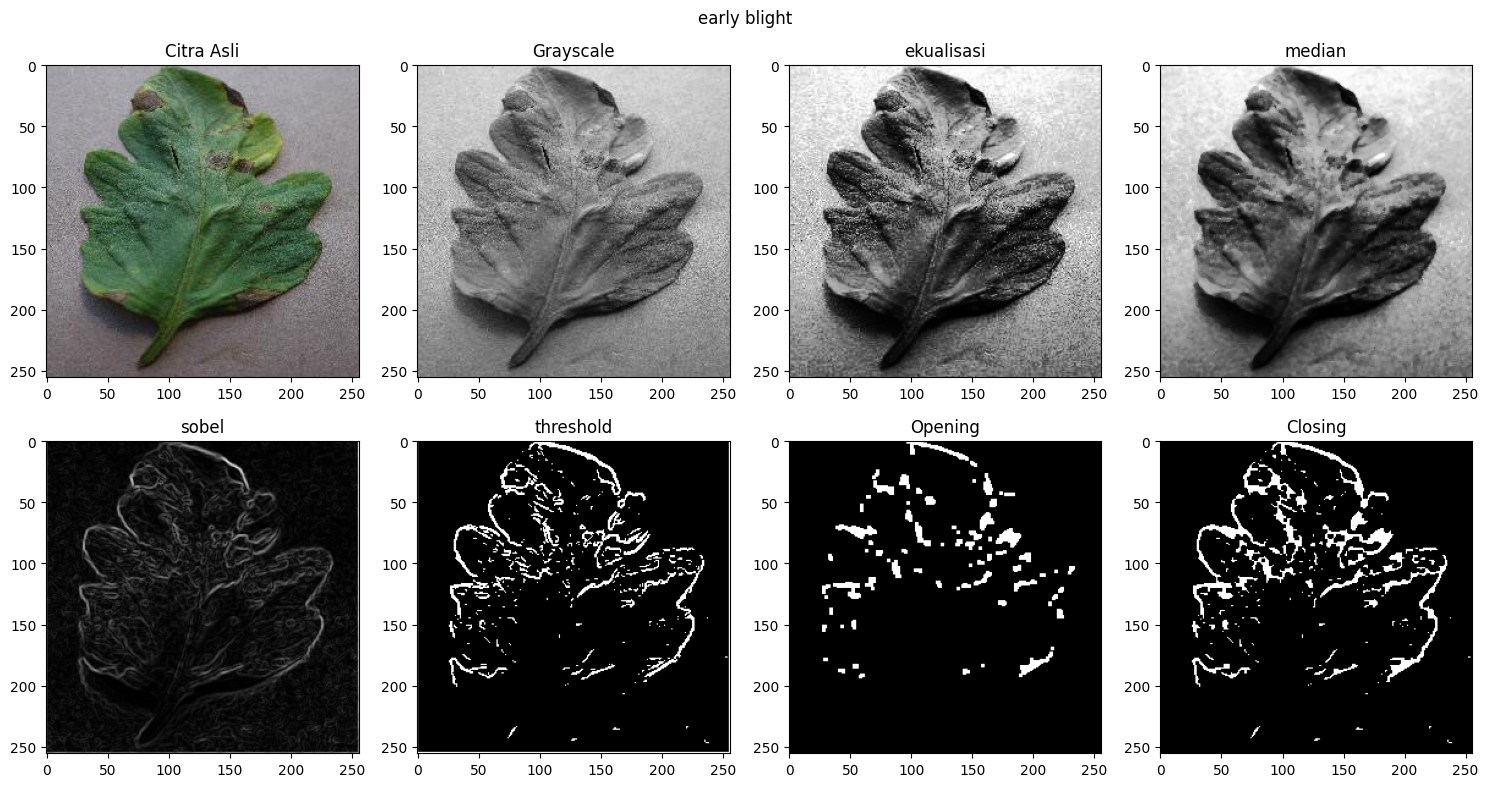

In [187]:
p3_gray = cv2.cvtColor(img3, cv2.COLOR_RGB2GRAY)
p3_he = ekualisasi_histogram(p3_gray)
p3_median = filtering(p3_he, 3, 'median')
p3_Tepi = deteksiTepi(p3_median, Sx, Sy)
p3_thresh = threshold(p3_Tepi, 200)


p3_closing = closing(p3_thresh, kernel)
p3_opening = opening(p3_closing, kernel)

plt.figure(figsize=(15, 8))

plt.subplot(2, 4, 1)
plt.imshow(img3)
plt.title('Citra Asli')
plt.axis('on')

plt.subplot(2, 4, 2)
plt.imshow(p3_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('on')

plt.subplot(2, 4, 3)
plt.imshow(p3_he, cmap='gray')
plt.title('ekualisasi')
plt.axis('on')

plt.subplot(2, 4, 4)
plt.imshow(p3_median, cmap='gray')
plt.title('median')
plt.axis('on')

plt.subplot(2, 4, 5)
plt.imshow(p3_Tepi, cmap='gray')
plt.title('sobel')
plt.axis('on')

plt.subplot(2, 4, 6)
plt.imshow(p3_thresh, cmap='gray')
plt.title('threshold')
plt.axis('on')

plt.subplot(2, 4, 7)
plt.imshow(p3_opening, cmap='gray')
plt.title('Opening')
plt.axis('on')

plt.subplot(2, 4, 8)
plt.imshow(p3_closing, cmap='gray')
plt.title('Closing')
plt.axis('on')

plt.suptitle('early blight')
plt.tight_layout()
plt.show()

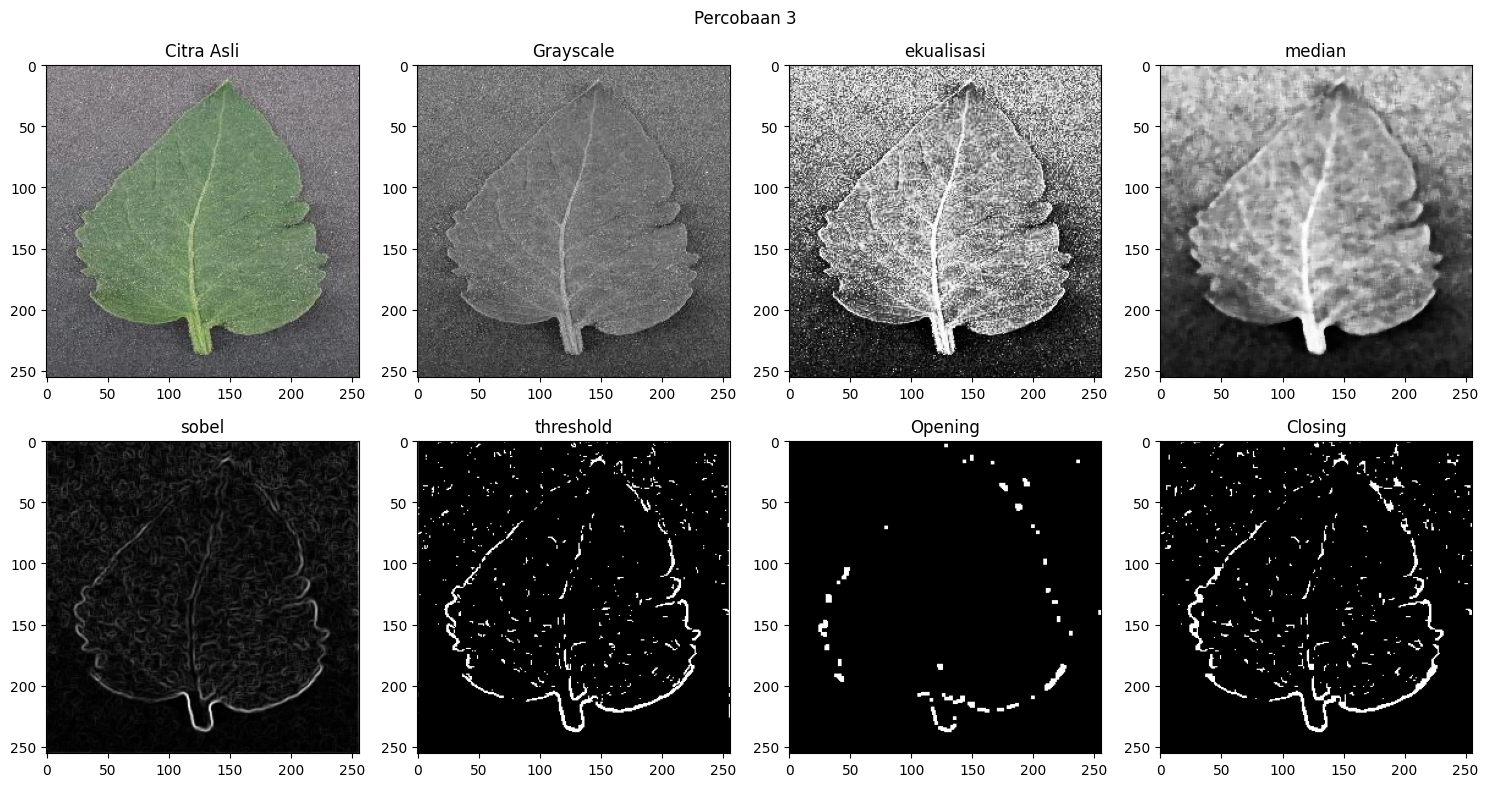

In [ ]:
p3_gray = cv2.cvtColor(img4, cv2.COLOR_RGB2GRAY)
p3_he = ekualisasi_histogram(p3_gray)
p3_median = filtering(p3_he, 5, 'median')
p3_Tepi = deteksiTepi(p3_median, Sx, Sy)
p3_thresh = threshold(p3_Tepi, 200)


p3_closing = closing(p3_thresh, kernel)
p3_opening = opening(p3_closing, kernel)

plt.figure(figsize=(15, 8))

plt.subplot(2, 4, 1)
plt.imshow(img4)
plt.title('Citra Asli')
plt.axis('on')

plt.subplot(2, 4, 2)
plt.imshow(p3_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('on')

plt.subplot(2, 4, 3)
plt.imshow(p3_he, cmap='gray')
plt.title('ekualisasi')
plt.axis('on')

plt.subplot(2, 4, 4)
plt.imshow(p3_median, cmap='gray')
plt.title('median')
plt.axis('on')

plt.subplot(2, 4, 5)
plt.imshow(p3_Tepi, cmap='gray')
plt.title('sobel')
plt.axis('on')

plt.subplot(2, 4, 6)
plt.imshow(p3_thresh, cmap='gray')
plt.title('threshold')
plt.axis('on')

plt.subplot(2, 4, 7)
plt.imshow(p3_opening, cmap='gray')
plt.title('Opening')
plt.axis('on')

plt.subplot(2, 4, 8)
plt.imshow(p3_closing, cmap='gray')
plt.title('Closing')
plt.axis('on')


plt.suptitle('Percobaan 3')
plt.tight_layout()
plt.show()